# Data Science Final Project: Titanic Survival Analysis

### By Kaiping Liu, Nick Zhu

This project analyzes the Titanic dataset to understand factors that influenced passenger survival rates. We will explore the data, perform statistical tests, examine variable relationships, build predictive models, and visualize our findings.

**Dataset Source**: https://www.kaggle.com/c/titanic/data

In [1]:
# Import necessary libraries
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy import stats
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Description

### 1.1 Data Source and Loading

In [2]:
# Load all three CSV files and merge them into a complete dataset
# Step 1: Load training data (with Survived column)
df_train = pd.read_csv("traintitanic.csv")

# Step 2: Load test data features (without Survived column)
X_test = pd.read_csv("testtitanic.csv")

# Step 3: Load test data labels (Survived column for test set)
y_test = pd.read_csv("gender_submission.csv")

# Step 4: Merge test features with test labels
df_test = pd.merge(X_test, y_test, on="PassengerId")

# Step 5: Combine training and test data into a complete dataset
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")
print(f"Complete dataset shape: {df.shape}")
print(f"\nDataset contains {len(df)} total passenger records")
df.head()

Training set shape: (891, 12)
Test set shape: (418, 12)
Complete dataset shape: (1309, 12)

Dataset contains 1309 total passenger records


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1.2 Data Overview and Information

The Titanic dataset contains information about passengers aboard the RMS Titanic. Let's examine the structure and characteristics of the data.

In [3]:
# Display basic information about the dataset
print("Dataset Info:")
print("=" * 50)
df.info()

print("\n\nDataset Description (All Variables):")
print("=" * 50)
print(df.describe(include='all'))

print("\n\nFirst few rows:")
print("=" * 50)
df.head(10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


Dataset Description (All Variables):
        PassengerId     Survived       Pclass                  Name   Sex  \
count   1309.000000  1309.000000  1309.000000                  1309  1309   
unique          NaN          NaN  

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### 1.4 Missing Data Analysis

In [4]:
# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Data Summary:")
print("=" * 50)
print(missing_df)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Total observations: {len(df)}")

Missing Data Summary:
          Missing Count  Percentage
Cabin              1014   77.463713
Age                 263   20.091673
Embarked              2    0.152788
Fare                  1    0.076394

Total missing values: 1280
Total observations: 1309


**Missing Data Concerns:**
- **Cabin**: 1014 missing values (77.46%) - Too many missing values to be useful for analysis.
- **Age**: 263 missing values (20.09%) - Substantial; needs careful imputation.
- **Embarked**: 2 missing values (0.15%) - Minimal; can impute with the mode.
- **Fare**: 1 missing value (0.08%) - Minimal; can impute with class-level median.

**Data Cleaning Strategy:**
1. Drop the `Cabin` column due to excessive missing data.
2. Impute missing `Age` values using median age grouped by Pclass and Sex.
3. Impute missing `Fare` using class-level median.
4. Impute missing `Embarked` values with the mode (keep all rows).

In [5]:
# Data cleaning and Feature Engineering
df_clean = df.copy()

# 1. Handle Age missing values
df_clean['Sex_num'] = (df_clean['Sex'] == 'male').astype(int)
df_clean['Age'] = df_clean['Age'].fillna(
    df_clean.groupby(['Pclass', 'Sex_num'])['Age'].transform('median')
)

# 2. Handle Fare missing values
df_clean['Fare'] = df_clean['Fare'].fillna(
    df_clean.groupby('Pclass')['Fare'].transform('median')
)

# 3. Handle Embarked (Fill with mode, keep all rows)
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Create C, Q, S
df_clean['C'] = (df_clean['Embarked'] == 'C').astype(int)
df_clean['Q'] = (df_clean['Embarked'] == 'Q').astype(int)
df_clean['S'] = (df_clean['Embarked'] == 'S').astype(int)

# 4. Drop columns (Keep Sex/Embarked for Viz, drop others)
cols_to_drop = ['Cabin', 'Ticket', 'Name', 'PassengerId']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

# 5. Age Binning
bins = [0, 10, 20, 30, 40, 50, 60, 80]
labels = ['0–10', '10–20', '20–30', '30–40', '40–50', '50–60', '60+']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, right=False)

print("Data Cleaning Completed.")
print(f"Shape after cleaning: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

Data Cleaning Completed.
Shape after cleaning: (1309, 13)
Missing values: 1


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_num,C,Q,S,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,1,0,0,1,20–30
1,1,1,female,38.0,1,0,71.2833,C,0,1,0,0,30–40
2,1,3,female,26.0,0,0,7.9250,S,0,0,0,1,20–30
3,1,1,female,35.0,1,0,53.1000,S,0,0,0,1,30–40
4,0,3,male,35.0,0,0,8.0500,S,1,0,0,1,30–40


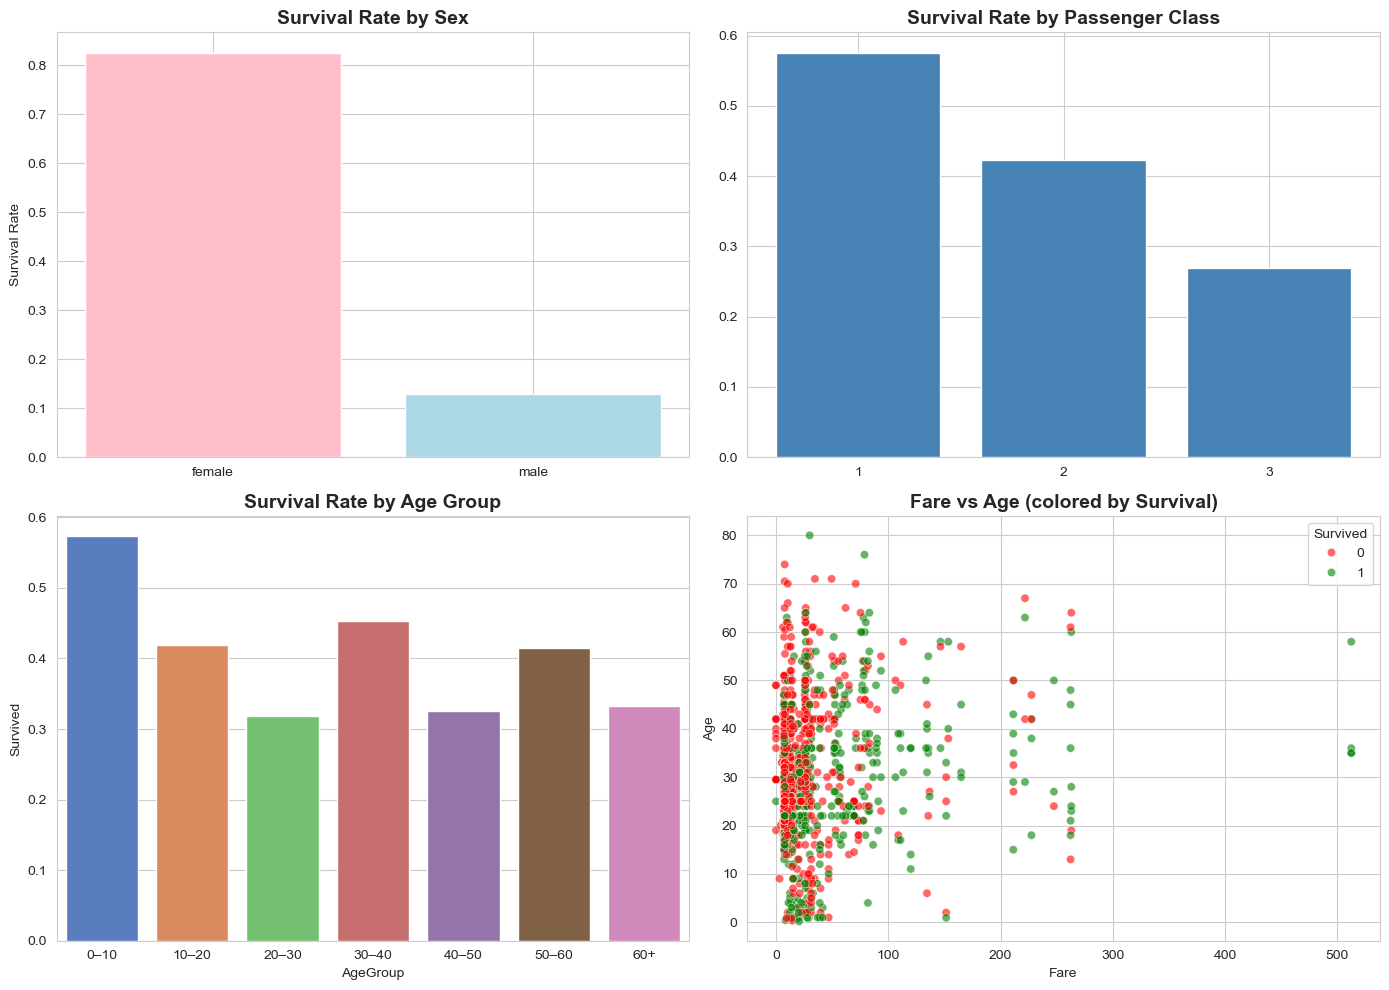

In [ ]:
# Visualization : Survival rate by different factors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival rate by Sex
sex_survival = df_clean.groupby('Sex')['Survived'].mean()
axes[0, 0].bar(sex_survival.index, sex_survival.values, color=['pink', 'lightblue'])
axes[0, 0].set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Survival Rate')

# 2. Survival rate by Pclass
pclass_survival = df_clean.groupby('Pclass')['Survived'].mean()
axes[0, 1].bar(pclass_survival.index.astype(str), pclass_survival.values, color='steelblue')
axes[0, 1].set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')

# 3. Survival Rate by Age Group
age_survival = df_clean.groupby('AgeGroup', observed=True)['Survived'].mean().reset_index()
sns.barplot(data=age_survival, x='AgeGroup', y='Survived', ax=axes[1, 0], palette='muted')
axes[1, 0].set_title('Survival Rate by Age Group', fontsize=14, fontweight='bold')

# 4. Fare vs Age
sns.scatterplot(data=df_clean, x='Fare', y='Age', hue='Survived', palette={0: 'red', 1: 'green'}, alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('Fare vs Age (colored by Survival)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.3 Data Characteristics

**Numerical Features:**
- `PassengerId`: Unique identifier for each passenger
- `Survived`: Target variable (0 = No, 1 = Yes)
- `Pclass`: Ticket class (1 = First, 2 = Second, 3 = Third)
- `Age`: Passenger age in years
- `SibSp`: Number of siblings/spouses aboard
- `Parch`: Number of parents/children aboard
- `Fare`: Ticket fare

**Categorical Features:**
- `Name`: Passenger name
- `Sex`: Gender (male/female)
- `Ticket`: Ticket number
- `Cabin`: Cabin number
- `Embarked`: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

In [ ]:
# Note: Data cleaning has already been completed in the visualization section above.
# The cleaned dataframe 'df_clean' is now available for all subsequent analysis.

print("Data cleaning summary:")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Survival rate: {df_clean['Survived'].mean():.3f}")

Data cleaning summary:
Cleaned dataset shape: (1309, 13)
Missing values: 1
Survival rate: 0.377


## 2. Variable Relationships

Let's examine correlations between variables to understand relationships in the data.

In [8]:
# Calculate correlation matrix
correlation_matrix = df_clean.corr(numeric_only=True)

print("Correlation with Survived:")
print("=" * 50)
print(correlation_matrix['Survived'].sort_values(ascending=False))

Correlation with Survived:
Survived    1.000000
Fare        0.233837
C           0.121156
Parch       0.108919
Q           0.040950
SibSp       0.002370
Age        -0.045667
S          -0.133020
Pclass     -0.264710
Sex_num    -0.688371
Name: Survived, dtype: float64


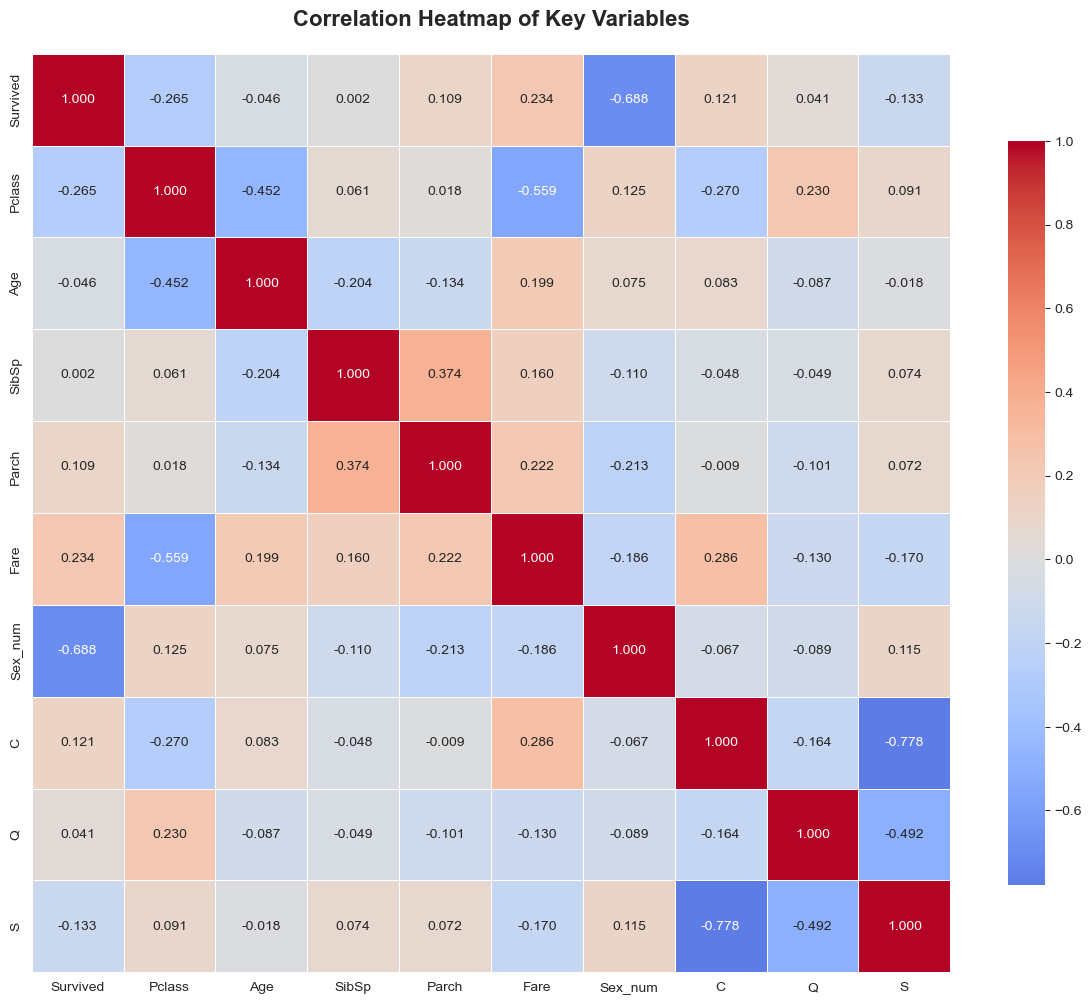

In [ ]:
# Visualization: Correlation heatmap
plt.figure(figsize=(12, 10))
# Using 'coolwarm' palette: Red for positive correlation, Blue for negative
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Analysis of Variable Relationships

The heatmap above highlights several meaningful relationships among key variables in the dataset:

**1. Strong, clear predictors:**
*   **`Sex_num`** shows the strongest association with survival (corr ≈ **-0.688**). This strong negative correlation indicates that being male significantly reduced the likelihood of survival.
*   **`Fare`** (corr ≈ **0.232**) and **`Pclass`** (corr ≈ **-0.262**) also show moderate to strong correlations, reflecting the impact of socioeconomic status.

**2. Ambiguous or weaker relationships:**
*   `Age`, `Parch`, `SibSp`, and `Embarked` (C, Q, S) show weaker direct linear correlations with the target variable.

**3. Structural correlations:**
*   Strong correlations exist among the dummy variables (**C, Q, S**) because a passenger can only belong to one port category (mutually exclusive).
*   **`SibSp`** and **`Parch`** show mixed signals: they correlate moderately with each other (0.373) but weakly with survival, suggesting that family size influences survival in complex, non-linear ways.

### 2.1 Statistical Test for Age

We investigate if the mean age differs significantly between survivors and non-survivors.

**Null Hypothesis (H₀)**: The mean age of survivors equals the mean age of non-survivors.

**Alternative Hypothesis (H₁)**: The mean age of survivors differs from the mean age of non-survivors.

In [10]:
# Two-sample t-test: Age of survivors vs. non-survivors
survivors_age = df_clean[df_clean['Survived'] == 1]['Age']
non_survivors_age = df_clean[df_clean['Survived'] == 0]['Age']

# Perform two-sample t-test
t_stat, p_value = stats.ttest_ind(survivors_age, non_survivors_age)

print("Two-Sample T-Test: Age of Survivors vs. Non-Survivors")
print("=" * 60)
print(f"Survivors - Mean age: {survivors_age.mean():.2f}, Std: {survivors_age.std():.2f}, n={len(survivors_age)}")
print(f"Non-survivors - Mean age: {non_survivors_age.mean():.2f}, Std: {non_survivors_age.std():.2f}, n={len(non_survivors_age)}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Two-Sample T-Test: Age of Survivors vs. Non-Survivors
Survivors - Mean age: 28.49, Std: 14.14, n=494
Non-survivors - Mean age: 29.73, Std: 12.61, n=815

T-statistic: -1.6527
P-value: 0.0986


**Interpretation:**

Based on the t-test results, the p-value is **0.0986**. At a significance level of α=0.05, we **fail to reject null hypothesis**.

There is no statistically significant difference in mean age between survivors and non-survivors in this dataset.

### 2.2 Statistical Test for SibSp (Siblings/Spouses)

We also investigate if the number of siblings/spouses (SibSp) differs significantly between survivors and non-survivors.

**Null Hypothesis (H₀)**: The mean SibSp of survivors equals the mean SibSp of non-survivors.

**Alternative Hypothesis (H₁)**: The mean SibSp of survivors differs from the mean SibSp of non-survivors.

In [11]:
# Two-sample t-test: SibSp of survivors vs. non-survivors
survivors_sibsp = df_clean[df_clean['Survived'] == 1]['SibSp']
non_survivors_sibsp = df_clean[df_clean['Survived'] == 0]['SibSp']

# Perform two-sample t-test
t_stat_sib, p_value_sib = stats.ttest_ind(survivors_sibsp, non_survivors_sibsp)

print("Two-Sample T-Test: SibSp of Survivors vs. Non-Survivors")
print("=" * 60)
print(f"Survivors - Mean SibSp: {survivors_sibsp.mean():.4f}, Std: {survivors_sibsp.std():.4f}, n={len(survivors_sibsp)}")
print(f"Non-survivors - Mean SibSp: {non_survivors_sibsp.mean():.4f}, Std: {non_survivors_sibsp.std():.4f}, n={len(non_survivors_sibsp)}")
print(f"\nT-statistic: {t_stat_sib:.4f}")
print(f"P-value: {p_value_sib:.4f}")

Two-Sample T-Test: SibSp of Survivors vs. Non-Survivors
Survivors - Mean SibSp: 0.5020, Std: 0.8000, n=494
Non-survivors - Mean SibSp: 0.4969, Std: 1.1645, n=815

T-statistic: 0.0857
P-value: 0.9317


**Interpretation:**

The p-value is approximately **0.93**, which is far greater than 0.05. We **fail to reject the null hypothesis**.

This suggests that there is **no statistically significant difference** in the average number of siblings/spouses between those who survived and those who did not. This aligns with our correlation analysis, which showed a near-zero correlation between `SibSp` and `Survived`.

### 2.3 Statistical Test for Parch (Parents/Children)

We now test whether the number of parents/children aboard (Parch) differs between survivors and non-survivors.

**Null Hypothesis (H₀)**: The mean Parch of survivors equals the mean Parch of non-survivors.

**Alternative Hypothesis (H₁)**: The mean Parch of survivors differs from the mean Parch of non-survivors.

In [12]:
# Two-sample t-test: Parch of survivors vs. non-survivors
survivors_parch = df_clean[df_clean['Survived'] == 1]['Parch']
non_survivors_parch = df_clean[df_clean['Survived'] == 0]['Parch']

# Perform two-sample t-test
t_stat_parch, p_value_parch = stats.ttest_ind(survivors_parch, non_survivors_parch)

print("Two-Sample T-Test: Parch of Survivors vs. Non-Survivors")
print("=" * 60)
print(f"Survivors - Mean Parch: {survivors_parch.mean():.4f}, Std: {survivors_parch.std():.4f}, n={len(survivors_parch)}")
print(f"Non-survivors - Mean Parch: {non_survivors_parch.mean():.4f}, Std: {non_survivors_parch.std():.4f}, n={len(non_survivors_parch)}")
print(f"T-statistic: {t_stat_parch:.4f}")
print(f"P-value: {p_value_parch:.4f}")

Two-Sample T-Test: Parch of Survivors vs. Non-Survivors
Survivors - Mean Parch: 0.5061, Std: 0.8888, n=494
Non-survivors - Mean Parch: 0.3117, Std: 0.8433, n=815
T-statistic: 3.9613
P-value: 0.0001


**Interpretation:**

The p-value is approximately **0.0001**, well below 0.05. We therefore **reject the null hypothesis**.

Survivors had a slightly higher average Parch (~0.51) than non-survivors (~0.31), indicating that traveling with parents/children is associated with higher survival odds, even though the effect size is modest.

## 3. Causal Interpretation

**Can the correlation between Sex and Survival be interpreted causally?**

**Answer: No, this correlation should NOT be interpreted causally.**

**Reasons:**
1. **Confounding Variables**: The relationship between sex and survival is likely confounded by other factors:
   - **"Women and children first" policy**: Historical accounts suggest that during the evacuation, there was a cultural norm prioritizing women and children for lifeboats, which would create a spurious correlation.
   - **Location on ship**: Women and children may have been located in areas closer to lifeboats or upper decks.
   - **Socioeconomic status**: Gender may be correlated with other factors like class, which also affects survival.

2. **Reverse Causality**: Survival cannot cause sex, but the relationship is not a direct causal effect of sex itself.

3. **Omitted Variable Bias**: Without controlling for other factors (like the evacuation procedures, location on ship, etc.), we cannot establish causality.

4. **Observational Data**: This is observational data from a historical event, not a randomized experiment. We cannot rule out that the relationship is due to other unobserved factors.

**Conclusion**: While there is a strong correlation between sex and survival, this is likely due to the "women and children first" evacuation protocol and other confounding factors, rather than a direct causal effect of sex on survival.

## 4. Predictive Model

We will build a logistic regression model to predict passenger survival. Logistic regression is appropriate here because our target variable (Survived) is binary (0 or 1).

### 4.1 Prepare Features

In [13]:
# Select features for the model
features_to_include = ['Pclass', 'Parch', 'Fare', 'Sex_num', 'C', 'S']
X = df_clean[features_to_include]
y = df_clean['Survived']

print("Features used:", X.columns.tolist())
print(f"Shape: {X.shape}")

Features used: ['Pclass', 'Parch', 'Fare', 'Sex_num', 'C', 'S']
Shape: (1309, 6)


### 4.2 Train-Test Split

In [14]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-Test Split:")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set survival rate: {y_train.mean():.3f}")
print(f"Test set survival rate: {y_test.mean():.3f}")

Train-Test Split:
Training set: 1047 samples (80.0%)
Test set: 262 samples (20.0%)

Training set survival rate: 0.377
Test set survival rate: 0.378


### 4.3 Train Logistic Regression Model

In [15]:
# Train logistic regression model
# Parameters:
# - penalty='l2': L2 regularization (Ridge) to prevent overfitting
# - C=1.0: Inverse of regularization strength (smaller C = stronger regularization)
# - max_iter=1000: Maximum iterations for convergence

lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained")
print("=" * 50)
print(f"Model parameters: penalty='l2', C=1.0, max_iter=1000")
print(f"Number of iterations: {lr_model.n_iter_[0]}")

Logistic Regression Model Trained
Model parameters: penalty='l2', C=1.0, max_iter=1000
Number of iterations: 75


### 4.4 Model Interpretation

In [17]:
# Display model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})
coefficients = coefficients.sort_values('Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
print("=" * 50)
print(coefficients.to_string(index=False))

Logistic Regression Coefficients:
Feature  Coefficient
   Fare     0.003340
  Parch    -0.172805
      S    -0.261205
      C    -0.303179
 Pclass    -0.724112
Sex_num    -3.555892


**Interpretation:**

Coefficients reflect log-odds impacts for features `Pclass`, `Parch`, `Fare`, `Sex_num`, `C`, and `S`.

- **Sex_num (male)** has the largest negative coefficient (~-3.56), confirming gender drives survival odds.
- **Pclass** is strongly negative; lower classes reduce survival odds. **Embarked C/S** are mildly negative once other factors are controlled.
- **Fare** has a small positive effect, while **Parch** is slightly negative after controlling for class and sex.

Overall, higher fare, higher class, and being female improve predicted survival; traveling with parents/children alone does not offset the disadvantage of lower class or being male.

### Visualizing Logistic Regression Fit
To evaluate the model's performance, we visualize the relationship between the most significant feature (`Sex_num`) and the target (`Survived`).

We use `sns.regplot` with `logistic=True` to fit a logistic sigmoid curve to the data:
* **Left Plot (Actual Data):** Displays the ground truth relationship from the original dataset.
* **Right Plot (Model Predictions):** Displays the relationship derived from the model's predictions.
Comparing these plots helps verify if the model's predicted probabilities follow the same distribution pattern as the actual data.

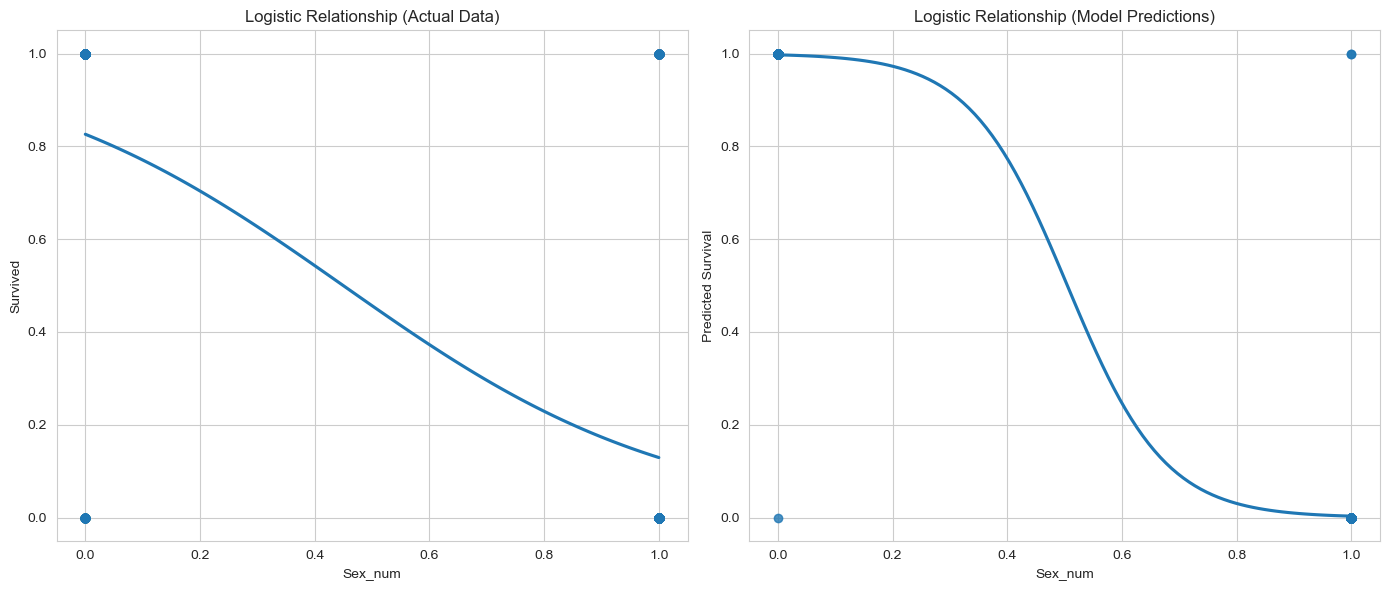

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(x= df_clean['Sex_num'] , y= df_clean['Survived'], logistic=True, ci=None, ax=axes[0])

axes[0].set_title('Logistic Relationship (Actual Data)')
axes[0].set_xlabel('Sex_num')
axes[0].set_ylabel('Survived')

y_train_pred = lr_model.predict(X_train)
sns.regplot(x= X_train['Sex_num'] , y= y_train_pred, logistic=True, ci=None, ax=axes[1])
axes[1].set_title('Logistic Relationship (Model Predictions)')
axes[1].set_xlabel('Sex_num')
axes[1].set_ylabel('Predicted Survival')

plt.tight_layout()
plt.show()

### 4.5 In-Sample Performance (Training Set)

In [19]:
# Predictions on training set
y_train_pred = lr_model.predict(X_train)
y_train_proba = lr_model.predict_proba(X_train)[:, 1]

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

print("In-Sample Performance (Training Set):")
print("=" * 50)
print(f"Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

print("\nClassification Report:")
print("-" * 50)
print(classification_report(y_train, y_train_pred, target_names=['Did Not Survive', 'Survived']))

print("\nConfusion Matrix:")
print("-" * 50)
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)
print(f"\nTrue Negatives: {cm_train[0,0]}, False Positives: {cm_train[0,1]}")
print(f"False Negatives: {cm_train[1,0]}, True Positives: {cm_train[1,1]}")

In-Sample Performance (Training Set):
Accuracy: 0.8586 (85.86%)

Classification Report:
--------------------------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.88      0.90      0.89       652
       Survived       0.83      0.79      0.81       395

       accuracy                           0.86      1047
      macro avg       0.85      0.85      0.85      1047
   weighted avg       0.86      0.86      0.86      1047


Confusion Matrix:
--------------------------------------------------
[[587  65]
 [ 83 312]]

True Negatives: 587, False Positives: 65
False Negatives: 83, True Positives: 312


### 4.6 Out-of-Sample Performance (Test Set)

In [20]:
# Predictions on test set
y_test_pred = lr_model.predict(X_test)
y_test_proba = lr_model.predict_proba(X_test)[:, 1]

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Out-of-Sample Performance (Test Set):")
print("=" * 50)
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\nClassification Report:")
print("-" * 50)
print(classification_report(y_test, y_test_pred, target_names=['Did Not Survive', 'Survived']))

print("\nConfusion Matrix:")
print("-" * 50)
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)
print(f"\nTrue Negatives: {cm_test[0,0]}, False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}, True Positives: {cm_test[1,1]}")

print("\n\nModel Performance Summary:")
print("=" * 50)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference: {abs(train_accuracy - test_accuracy):.4f}")

Out-of-Sample Performance (Test Set):
Accuracy: 0.8435 (84.35%)

Classification Report:
--------------------------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.90      0.88       163
       Survived       0.82      0.75      0.78        99

       accuracy                           0.84       262
      macro avg       0.84      0.82      0.83       262
   weighted avg       0.84      0.84      0.84       262


Confusion Matrix:
--------------------------------------------------
[[147  16]
 [ 25  74]]

True Negatives: 147, False Positives: 16
False Negatives: 25, True Positives: 74


Model Performance Summary:
Training Accuracy: 0.8586 (85.86%)
Test Accuracy: 0.8435 (84.35%)
Difference: 0.0151


**Model Performance Analysis:**

- Accuracy: **85.86%** (train) vs **84.35%** (test); ~1.5% gap suggests good generalization.
- Confusion (test): TN=147, FP=16, FN=25, TP=74.
- Class metrics (test): Did Not Survive — precision 0.85, recall 0.90; Survived — precision 0.82, recall 0.75 (F1=0.78).
- The model misses more survivors than non-survivors, reflecting the class imbalance and the conservative threshold on predicting survival.